In [1]:
#Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
sb.set()

In [6]:
#  checking what the cleaned dataset looks like


print("Shape:", cardio_clean.shape)

print("\nColumns:")
print(cardio_clean.columns.tolist())

# quick preview
cardio_clean.head()

Shape: (70000, 13)

Columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


cardio
0    35021
1    34979
Name: count, dtype: int64


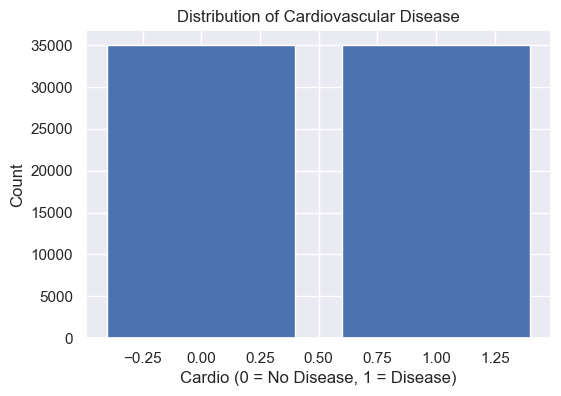

In [7]:
# checking to see if the dataset is balanced or not
# if it is too skewed, later analysis might be misleading

cardio_counts = cardio_clean["cardio"].value_counts().sort_index()
print(cardio_counts)

plt.figure(figsize=(6,4))
plt.bar(cardio_counts.index, cardio_counts.values)

plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")

plt.show()

In [8]:
# checking which variables are most related to cardio
# this helps identify the "important factors" for our question statement

cardio_corr = cardio_clean.corr(numeric_only=True)["cardio"].sort_values(ascending=False)
print(cardio_corr)

cardio         1.000000
age            0.238159
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
gender         0.008109
id             0.003799
alco          -0.007330
height        -0.010821
smoke         -0.015486
active        -0.035653
Name: cardio, dtype: float64


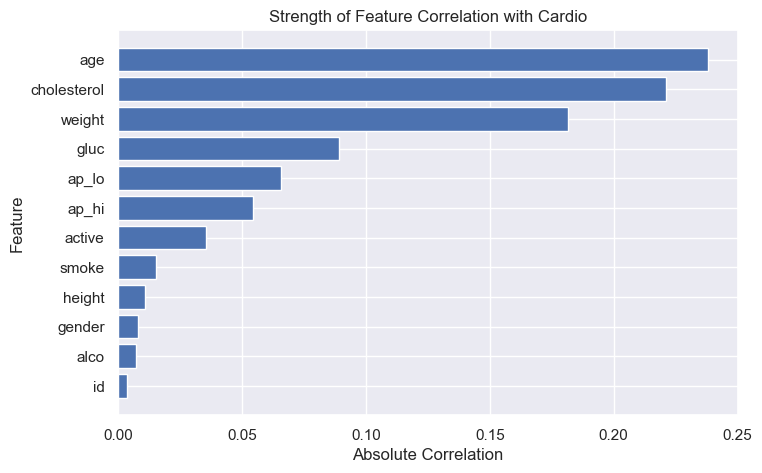

In [9]:
# plotting correlation values to make it easier to compare
# using absolute value since both + and - matter for strength

top_corr = cardio_clean.corr(numeric_only=True)["cardio"].drop("cardio").abs().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.barh(top_corr.index, top_corr.values)

plt.title("Strength of Feature Correlation with Cardio")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.show()

In [12]:
# if cleaning cells weren't run yet, this makes sure
# the columns needed for my EDA are available

# rename BP columns to cleaned names if needed
if "ap_hi" in cardio_clean.columns and "bp_systolic" not in cardio_clean.columns:
    cardio_clean = cardio_clean.rename(columns={"ap_hi": "bp_systolic"})

if "ap_lo" in cardio_clean.columns and "bp_diastolic" not in cardio_clean.columns:
    cardio_clean = cardio_clean.rename(columns={"ap_lo": "bp_diastolic"})

# create bmi only if it's not already there
if "bmi" not in cardio_clean.columns:
    cardio_clean["bmi"] = cardio_clean["weight"] / ((cardio_clean["height"] / 100) ** 2)
    cardio_clean["bmi"] = cardio_clean["bmi"].round(2)

# create pulse pressure only if it's not already there
if "pulse_pressure" not in cardio_clean.columns:
    cardio_clean["pulse_pressure"] = cardio_clean["bp_systolic"] - cardio_clean["bp_diastolic"]

# just checking
print(cardio_clean.columns.tolist())
cardio_clean.head()

['id', 'age', 'gender', 'height', 'weight', 'bp_systolic', 'bp_diastolic', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi', 'pulse_pressure']


,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse_pressure
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,30
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,50
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,40


<Figure size 600x400 with 0 Axes>

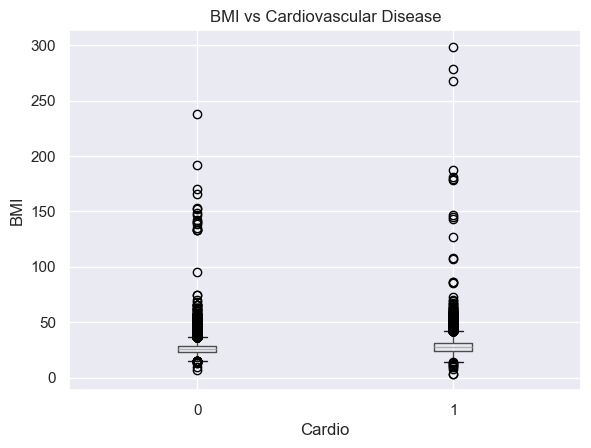

In [14]:
# bmi already available now
# just checking if the cardio group tends to have higher bmi

plt.figure(figsize=(6,4))
cardio_clean.boxplot(column="bmi", by="cardio")

plt.title("BMI vs Cardiovascular Disease")
plt.suptitle("")
plt.xlabel("Cardio")
plt.ylabel("BMI")

plt.show()

<Figure size 600x400 with 0 Axes>

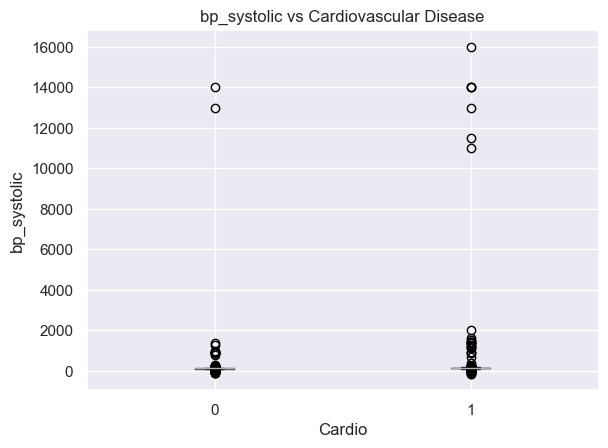

<Figure size 600x400 with 0 Axes>

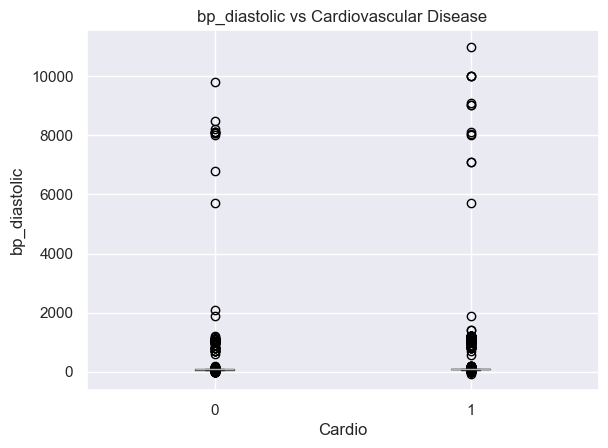

In [15]:
# comparing systolic and diastolic BP across cardio groups
# these should be strong clinical indicators

for col in ["bp_systolic", "bp_diastolic"]:
    plt.figure(figsize=(6,4))
    cardio_clean.boxplot(column=col, by="cardio")

    plt.title(f"{col} vs Cardiovascular Disease")
    plt.suptitle("")
    plt.xlabel("Cardio")
    plt.ylabel(col)

    plt.show()

<Figure size 600x400 with 0 Axes>

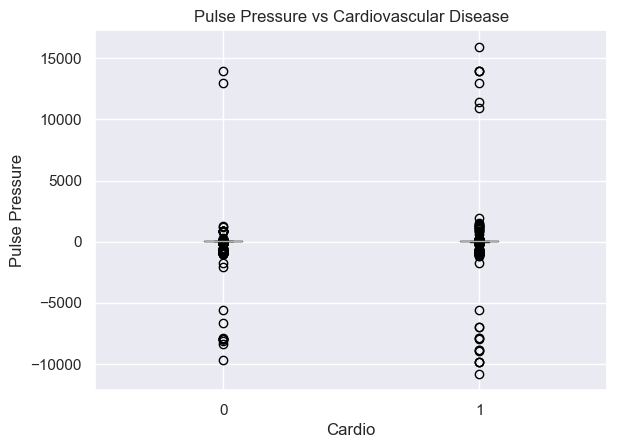

In [16]:
# pulse pressure = systolic - diastolic
# checking if there's a visible difference between groups

plt.figure(figsize=(6,4))
cardio_clean.boxplot(column="pulse_pressure", by="cardio")

plt.title("Pulse Pressure vs Cardiovascular Disease")
plt.suptitle("")
plt.xlabel("Cardio")
plt.ylabel("Pulse Pressure")

plt.show()

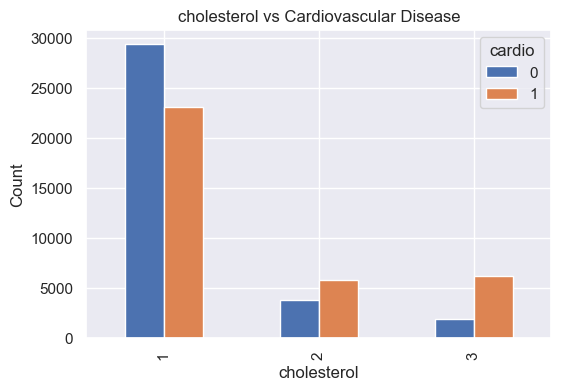

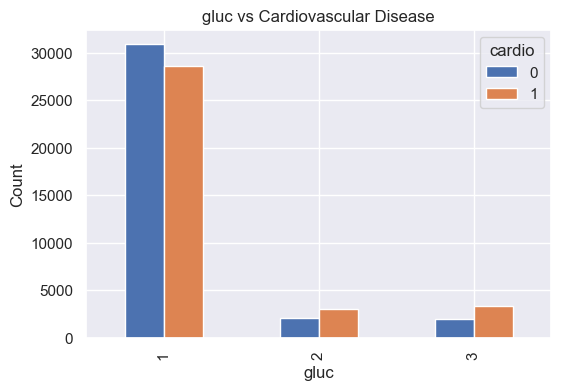

In [17]:
# checking how cardio cases are spread across cholesterol and glucose levels

for col in ["cholesterol", "gluc"]:
    grouped = cardio_clean.groupby([col, "cardio"]).size().unstack(fill_value=0)

    grouped.plot(kind="bar", figsize=(6,4))
    plt.title(f"{col} vs Cardiovascular Disease")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

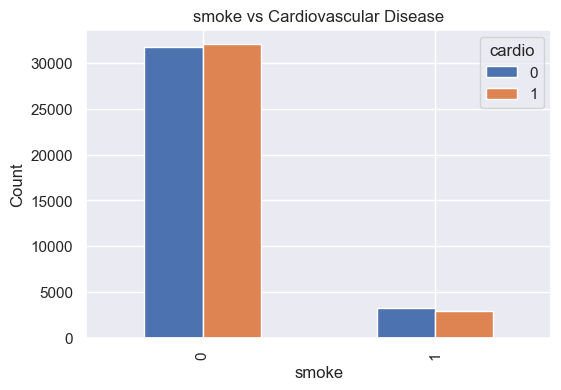

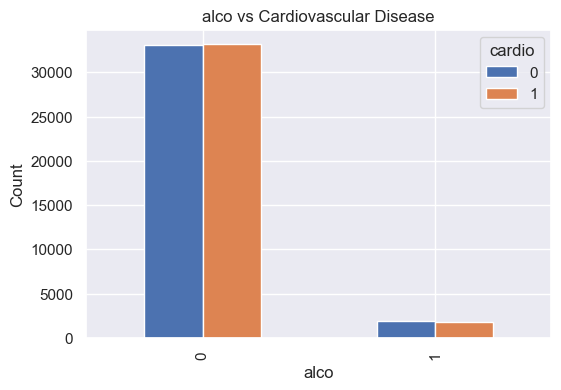

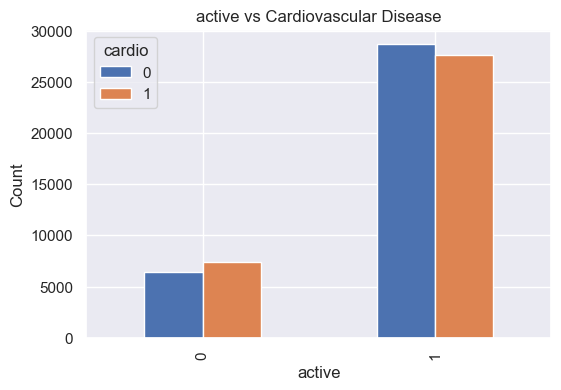

In [19]:
# checking smoking, alcohol and physical activity
# these are lifestyle factors so pattern may be weaker

for col in ["smoke", "alco", "active"]:
    grouped = cardio_clean.groupby([col, "cardio"]).size().unstack(fill_value=0)

    grouped.plot(kind="bar", figsize=(6,4))
    plt.title(f"{col} vs Cardiovascular Disease")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

In [20]:
# counts can be misleading if one category has more people
# so this checks the actual disease rate within each group

for col in ["cholesterol", "gluc", "smoke", "alco", "active"]:
    print(f"\nCardio rate by {col}:")
    print(cardio_clean.groupby(col)["cardio"].mean().round(3))


Cardio rate by cholesterol:
cholesterol
1    0.440
2    0.602
3    0.765
Name: cardio, dtype: float64

Cardio rate by gluc:
gluc
1    0.481
2    0.593
3    0.622
Name: cardio, dtype: float64

Cardio rate by smoke:
smoke
0    0.502
1    0.475
Name: cardio, dtype: float64

Cardio rate by alco:
alco
0    0.501
1    0.484
Name: cardio, dtype: float64

Cardio rate by active:
active
0    0.536
1    0.491
Name: cardio, dtype: float64


In [21]:
# checking which numerical variables are most related to cardio overall

cardio_corr = cardio_clean.corr(numeric_only=True)["cardio"].sort_values(ascending=False)
print(cardio_corr)

cardio            1.000000
age               0.238159
cholesterol       0.221147
weight            0.181660
bmi               0.165633
gluc              0.089307
bp_diastolic      0.065719
bp_systolic       0.054475
gender            0.008109
id                0.003799
alco             -0.007330
height           -0.010821
smoke            -0.015486
pulse_pressure   -0.016550
active           -0.035653
Name: cardio, dtype: float64


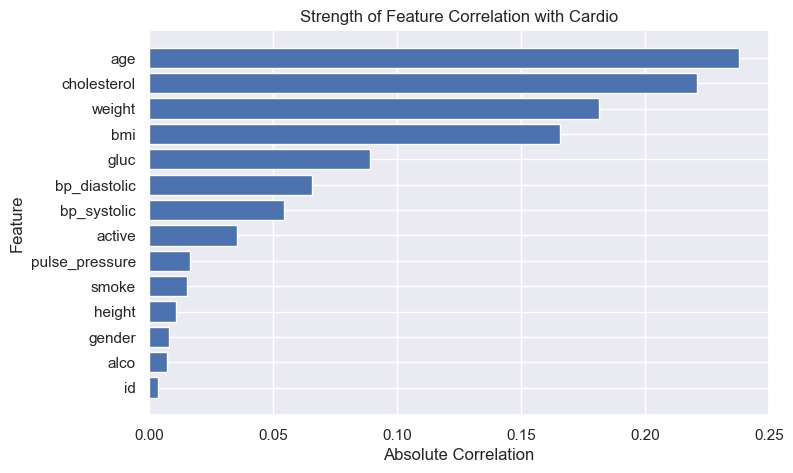

In [22]:
# easier to compare the strength visually
# using absolute value because strength matters more than sign here

corr_strength = cardio_clean.corr(numeric_only=True)["cardio"].drop("cardio").abs().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.barh(corr_strength.index, corr_strength.values)

plt.title("Strength of Feature Correlation with Cardio")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.show()

In [23]:
# short wrap-up before handing over to ML part

print("""
EDA Summary

- Blood pressure, BMI and pulse pressure show clearer differences between cardio groups.
- Cholesterol and glucose are also associated with higher cardio rates.
- Lifestyle factors such as smoking and alcohol show weaker patterns compared to clinical indicators.
- Overall, clinical indicators seem more strongly associated with cardiovascular disease.
""")


EDA Summary

- Blood pressure, BMI and pulse pressure show clearer differences between cardio groups.
- Cholesterol and glucose are also associated with higher cardio rates.
- Lifestyle factors such as smoking and alcohol show weaker patterns compared to clinical indicators.
- Overall, clinical indicators seem more strongly associated with cardiovascular disease.

